<span style="Color: olive; font-size:40px">**LOADING, EXPLORATION, QC, AND DOUBLET DETECTION**</span>

⚠️  <span style="color: orange; font-size:18px">***Restart Kernel***</span>

<span style="font-size:16px; font-weight:bold"> In this notebook, data will be loaded, quality controlled, and doublets will be detected and deleted. </span> 

<span style="font-size:16px; color:red; font-weight:bold"> <strong>Note:</strong> All newly created notebooks must include an initial cell for environment setup and memory usage management. </span>

<span style="color:olive; font-size:16px">**Import libraries**</span>

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import psutil
import gc
import os
import zipfile
import scrublet as scr                  # for doublet detection
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

In [3]:

sc.settings.n_jobs     = 4                  # Use multiple CPU cores for parallel processing (if supported by the function)
sc.settings.verbosity  = 2              # Set verbosity level (0 = errors only, 1 = warnings, 2 = info, 3 = debug)  
sc.settings.figdir     = '../results/'    # Directory to save figures
np.random.seed(42)                        # np.random.seed(42) sets the seed for NumPy's random number generator to ensure reproducibility of results. 
# By using the same seed value (42 in this case), you can ensure that the random numbers generated by NumPy will be the same each time you run the code, which is important for debugging and sharing results with others.

def check_ram():
    ram = psutil.Process().memory_info().rss / 1e9
    print(f"RAM in use: {ram:.1f} GB")
    if ram > 11:
        print("⚠️ High RAM — consider restarting kernel soon")

def find_matrix_folder(patient_dir):
    for subfolder in patient_dir.iterdir():
        if subfolder.is_dir() and any(subfolder.rglob('*.mtx*')):
            return subfolder
    return None

raw_dir  = Path('../data/Raw_matrix')
ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)

print("✅ All libraries loaded — ready to start Block 2")
check_ram()

✅ All libraries loaded — ready to start Block 2
RAM in use: 0.4 GB


<span style="color:maroon; font-size:12px">**Suggestion from Joan**: instead of using <code>print</code> to track the loading process, we can use a progress bar library like <code>tqdm</code>to visually represent the loading progress. This can provide a more intuitive and user-friendly way to monitor the loading process, espaciallly when working with a large number of datasets. 

<span style="font-size:18px; color: olive">***Explore patient 1 (Pt1) metadata structure to understand the data format and plan the loading strategy.***</span>

In [ ]:
raw_dir=Path('../data/Raw_matrix')

pid='Pt1'
fbm=find_matrix_folder(raw_dir / pid)
adata_pt1=sc.read_10x_mtx(fbm, var_names='gene_symbols', cache=False, gex_only=True)
adata_pt1.var_names_make_unique()
print(f"✅ Successfully loaded {pid} with {adata_pt1.n_obs:,} cells | {adata_pt1.n_vars:,} genes")

✅ Successfully loaded Pt1 with 2,896       cells | 33,694 genes


   - <span style="font-size:15px; color:teal">**General structure**</span>

In [46]:
print("=" * 80)
print(f"  General structure of patient:: {pid}")
print("=" * 80)
print(adata_pt1)
print()
print(f"  Cells    (obs): {adata_pt1.n_obs:>10,}")
print(f"  Genes    (var): {adata_pt1.n_vars:>10,}")
print(f"  Matrix type: {type(adata_pt1.X)}")

  General structure of patient:: Pt1
AnnData object with n_obs × n_vars = 2896 × 33694
    var: 'gene_ids', 'feature_types'

  Cells    (obs):      2,896
  Genes    (var):     33,694
  Matrix type: <class 'scipy.sparse._csc.csc_matrix'>


   - <span style="font-size: 15px; color: teal">**Cells table (adata.obs)**</span>

      - <span style="font-size:14px; color: green">***Each row is a cell.***</span>

In [47]:
print("─" * 80)
print("  adata_pt1.obs  →  metadata per CELL (rows = cells)")      #each row is a cell.
print("─" * 80)
print(f"  Available columns: {list(adata_pt1.obs.columns)}")
print()
print(adata_pt1.obs.head(10))
print()
print(adata_pt1.obs.dtypes)

────────────────────────────────────────────────────────────────────────────────
  adata_pt1.obs  →  metadata per CELL (rows = cells)
────────────────────────────────────────────────────────────────────────────────
  Available columns: []

Empty DataFrame
Columns: []
Index: [AAACCCACAACGCATT-1, AAACCCAGTGAATGTA-1, AAACCCATCCATTCAT-1, AAACCCATCTTACCGC-1, AAACGAAAGCTAGCCC-1, AAACGAAAGCTCTGTA-1, AAACGAATCACGAACT-1, AAACGAATCCCGAACG-1, AAACGCTCACACAGAG-1, AAACGCTTCCACTGGG-1]

Series([], dtype: object)


   - <span style="color:teal; font-size:15px">**Genes table (adata_pt.var)**</span>

In [48]:
print("─" * 80)
print("  adata_pt1.var  →  metadata per GENE (rows = genes)")
print("─" * 80)
print(f"  Available columns: {list(adata_pt1.var.columns)}")
print()
print(adata_pt1.var.head(10))
print()
print(adata_pt1.var.dtypes)

────────────────────────────────────────────────────────────────────────────────
  adata_pt1.var  →  metadata per GENE (rows = genes)
────────────────────────────────────────────────────────────────────────────────
  Available columns: ['gene_ids', 'feature_types']

                      gene_ids    feature_types
RP11-34P13.3   ENSG00000243485  Gene Expression
FAM138A        ENSG00000237613  Gene Expression
OR4F5          ENSG00000186092  Gene Expression
RP11-34P13.7   ENSG00000238009  Gene Expression
RP11-34P13.8   ENSG00000239945  Gene Expression
RP11-34P13.14  ENSG00000239906  Gene Expression
RP11-34P13.9   ENSG00000241599  Gene Expression
FO538757.3     ENSG00000279928  Gene Expression
FO538757.2     ENSG00000279457  Gene Expression
AP006222.2     ENSG00000228463  Gene Expression

gene_ids         object
feature_types    object
dtype: object


   - <span style="font-size:15px; color:teal">**Matrix sparsity**</span>
      - <span style="font-size:14px; color:green"> The sparsity of a matrix is the proportion of zero entries. In scRNA-seq data, it's common to have a high sparsity (90-95%) because many genes are not expressed in many cells.</span>


In [49]:
import scipy.sparse as sp
matrix = adata_pt1.X
total_entries  = matrix.shape[0] * matrix.shape[1]
nonzero        = matrix.nnz
sparsity       = 1 - (nonzero / total_entries)
print(f"\n📊 MATRIX")
print(f"  Non-zero entries: {nonzero:,}")
print(f"  Sparsity:         {sparsity*100:.1f}%")
print(f"  Matrix type:      {type(matrix)}")


📊 MATRIX
  Non-zero entries: 6,135,817
  Sparsity:         93.7%
  Matrix type:      <class 'scipy.sparse._csc.csc_matrix'>


   - <span style="font-size:15px; color: teal">**Key genes present on this patient?**</span>

      - <span style="font-size:14px; color:green">***Check for the presence of key genes relevant to GBM biology, such as VEGFA, KDR, ESM1 (endothelial markers), TRDC, TRDV2, CD3D (T cell markers), CD68 (macrophage marker), PECAM1 (endothelial marker), TMEM119 (microglia marker), and FOXP3 (regulatory T cell marker).***</span>

In [ ]:
key_genes = ['VEGFA','KDR','ESM1','TRDC','TRDV2','CD3D',
             'CD68','PECAM1','TMEM119','FOXP3']
print(f"\n🧬 KEY GENES")
for g in key_genes:
    status = "✅" if g in adata_pt1.var_names else "❌ MISSING"
    print(f"  {status}  {g}")


🧬 KEY GENES
  ✅  VEGFA
  ✅  KDR
  ✅  ESM1
  ✅  TRDC
  ✅  TRDV2
  ✅  CD3D
  ✅  CD68
  ✅  PECAM1
  ✅  TMEM119
  ✅  FOXP3


   - <span style="font-size:15px; color: teal">**Transform AnnData to a DataFrame to view the raw count matrix.**</span>
      - <span style="font-size:14px; color: green">**Count matrix (adata.X)**</span>

In [51]:
adata_pt1_df=adata_pt1.to_df()

In [52]:
adata_pt1_df

,RP11-34P13.3,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,RP11-34P13.14,RP11-34P13.9,FO538757.3,FO538757.2,AP006222.2,...,AC007325.2,BX072566.1,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1,AC213203.1,FAM231B
AAACCCACAACGCATT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
AAACCCAGTGAATGTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCATCCATTCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCATCTTACCGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAAAGCTAGCCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGAGGTTCACCGG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTAGGAAGAAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCTCAGGCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTTGAGCCGATAG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
check_ram()

RAM in use: 0.4 GB


   - <span style="color: teal; font-size:15px">**Visual summary of raw data files (three 10x files)**</span>

In [56]:
print("─" * 80)
print("  Source files (10x Genomics format)")
print("─" * 80)
files = {
    "matrix.mtx(.gz)": "Sparse matrix of UMI counts (rows=genes, cols=cells)",   #Matriz dispersa de conteos UMI (filas=genes, cols=células)
    "barcodes.tsv(.gz)": "List of sequenced cell barcodes",                      #Lista de códigos de barras de células secuenciadas
    "features.tsv(.gz)": "List of genes with Ensembl ID and name"                #Lista de genes con ID de Ensembl y nombre
}
for file, description in files.items():
    print(f"  📄 {file:<25} → {description}")

────────────────────────────────────────────────────────────────────────────────
  Source files (10x Genomics format)
────────────────────────────────────────────────────────────────────────────────
  📄 matrix.mtx(.gz)           → Sparse matrix of UMI counts (rows=genes, cols=cells)
  📄 barcodes.tsv(.gz)         → List of sequenced cell barcodes
  📄 features.tsv(.gz)         → List of genes with Ensembl ID and name


In [ ]:
del adata_pt1; gc.collect()
del adata_pt1_df; gc.collect()

<span style="color: olive; font-size:18px">**LOAD ALL PATIENTS DATA**</span>

<span style="font-size:16px">Due to memory limitations, I decided to analyse only 12 patients instead of all 24. I will compare **Newly diagnosed (ND)** and **Recurrent (R)** patients, which are the two main groups of interest in this study. I'll compare both groups to identify differences in cell type composition, gene expression profiles, and other relevant features. This approach allows me to focus on the most clinically relevant comparisons while managing memory constraints effectively.</span>

<span style="color:red; font-size:12px">**What happened before I decided to analyze only half of the patients?**</span>

   - <span style="font-size:11px">For the samples from Pt1–Pt18 and mouse samples, scRNA-seq was performed using Chromium Single Cell Library kits (10x Genomics). For the samples from Pt19–Pt24, scRNA-seq was performed with GEX-SCOPE Single Cell RNA Library kits (Singleron). **The difference in library preparation methods likely led to differences in the gene sets captured**, resulting in the observed discrepancy in the gene universe between the two groups of patients.</span> <span style="font-size:14px">[1]</span>

   - <span style="font-size:11px">We have a **dual sequencing KIT problem**: *10x Genomics Chromium (Pt1–Pt18)* vs *Singleron GEX-SCOPE (Pt19–Pt24)*. Critically, a GEO record for a dataset using both kits confirms: both were mapped to GRCh38 with Ensembl v92.

<span style="font-size:12px">[1] Mei, Y., Wang, X., Zhang, J., Liu, D., He, J., Huang, C., Liao, J., Wang, Y., Feng, Y., Li, H., Liu, X., Chen, L., Yi, W., Chen, X., Bai, H. M., Wang, X., Li, Y., Wang, L., Liang, Z., … Jia, G. (2023). Siglec-9 acts as an immune-checkpoint molecule on macrophages in glioblastoma, restricting T-cell priming and immunotherapy response. Nature Cancer, 4(9), 1273–1291. https://doi.org/10.1038/s43018-023-00598-9

In [ ]:
from tqdm import tqdm

group_map = {
    'Pt1':'ND',  'Pt3':'Rec',  'Pt4':'ND',  'Pt5':'ND',
    'Pt6':'Rec', 'Pt7':'Rec', 'Pt8':'Rec', 'Pt9':'ND', 'Pt10':'ND',
    'Pt12':'Rec','Pt13':'ND',  'Pt14':'ND'
}

# Verify completeness of group_map
from collections import Counter
counts = Counter(group_map.values())
print("=== group_map ===")
for grp, n in sorted(counts.items()):
    pids = [k for k,v in group_map.items() if v == grp]
    print(f"  {grp}: n={n} → {pids}")

# ── Load only patients in group_map ──────────────────────────
adatas = []

for patient_dir in tqdm(
    sorted(raw_dir.iterdir(),
           key=lambda x: int(''.join(filter(str.isdigit, x.name)))),
    desc='Loading patients', unit='patient'
):
    if not patient_dir.is_dir():
        continue

    pid = patient_dir.name

    # Skip patients not in group_map
    if pid not in group_map:
        tqdm.write(f" {pid}: not in group_map — skipping")
        continue

    fbm = find_matrix_folder(patient_dir)
    if fbm is None:
        tqdm.write(f" {pid}: matrix folder not found — skipping")
        continue

    adata_tmp = sc.read_10x_mtx(str(fbm), var_names='gene_symbols', gex_only=True)
    adata_tmp.var_names_make_unique()
    adata_tmp.obs['patient_id'] = pd.Categorical([pid] * adata_tmp.n_obs)
    adata_tmp.obs['condition']  = pd.Categorical(
        [group_map[pid]] * adata_tmp.n_obs   
    )
    adatas.append(adata_tmp)
    check_ram()
    tqdm.write(f"  {pid}: {adata_tmp.n_obs:,} cells | "
               f"{adata_tmp.n_vars:,} genes | "
               f"condition={group_map[pid]}")

print(f"\n✅ Loaded: {len(adatas)}/{len(group_map)} patients | "
      f"{sum(a.n_obs for a in adatas):,} total cells")

=== group_map ===
  ND: n=7 → ['Pt1', 'Pt4', 'Pt5', 'Pt9', 'Pt10', 'Pt13', 'Pt14']
  Rec: n=5 → ['Pt3', 'Pt6', 'Pt7', 'Pt8', 'Pt12']


Loading patients:   0%|          | 0/24 [00:00<?, ?patient/s]

Loading patients:   4%|▍         | 1/24 [00:02<00:56,  2.46s/patient]

RAM in use: 0.5 GB
  Pt1: 2,896 cells | 33,694 genes | condition=ND
 Pt2: not in group_map — skipping


Loading patients:  12%|█▎        | 3/24 [00:04<00:27,  1.31s/patient]

...

RAM in use: 1.3 GB
  Pt12: 1,894 cells | 33,694 genes | condition=Rec


Loading patients:  54%|█████▍    | 13/24 [00:46<00:31,  2.86s/patient]

RAM in use: 1.4 GB
  Pt13: 3,064 cells | 33,694 genes | condition=ND


Loading patients: 100%|██████████| 24/24 [00:49<00:00,  2.05s/patient]

RAM in use: 1.4 GB
  Pt14: 2,857 cells | 33,694 genes | condition=ND
 Pt15: not in group_map — skipping
 Pt16: not in group_map — skipping
 Pt17: not in group_map — skipping
 Pt18: not in group_map — skipping
 Pt19: not in group_map — skipping
 Pt20: not in group_map — skipping
 Pt21: not in group_map — skipping
 Pt22: not in group_map — skipping
 Pt23: not in group_map — skipping
 Pt24: not in group_map — skipping

✅ Loaded: 12/12 patients | 49,360 total cells


In [8]:
check_ram()

RAM in use: 1.4 GB


<span style="font-size:14px"><code>var_names_make_unique()</code> ensures that all gene names in the var component of the AnnData object are unique.

<span style="font-size:14px">**This is important because duplicate gene names can lead to confusion and errors in downstream analysis.**</span> <span style="font-size:14px">By making **gene names unique**, we can ensure that each gene can be accurately referenced and analyzed without ambiguity.</span>

<span style="font-size:16px; color: olive">**Verify gene universe before concatenation**</span>

   - <span style="font-size:14px; color:green">***Check that all patients have the same set of genes <span style="color:orange">(same gene universe)</span> before concatenating the data.***</span>

   - <span style="font-size:14px; color:green">***This is crucial because differences in gene sets across patients can lead to issues in downstream analysis, such as batch effects or missing data.***</span>  

In [9]:
# ── Verify gene universe before concat ───────────────────────
print("\n======================== Gene universe check ========================")
reference = set(adatas[0].var_names)            # adatas[0]--> is the first patient's AnnData object, and we are using its var_names (gene names) as the reference set for comparison with the other patients.
for a in adatas[1:]:
    pid  = a.obs['patient_id'][0]
    diff = reference.symmetric_difference(set(a.var_names))
    if diff:
        tqdm.write(f"  ⚠️ {pid}: {len(diff)} genes differ from Pt1")
    else:
        tqdm.write(f"  {pid}: gene universe identical ✅")


======================== Gene universe check ========================
  Pt3: gene universe identical ✅
  Pt4: gene universe identical ✅
  Pt5: gene universe identical ✅
  Pt6: gene universe identical ✅
  Pt7: gene universe identical ✅
  Pt8: gene universe identical ✅
  Pt9: gene universe identical ✅
  Pt10: gene universe identical ✅
  Pt12: gene universe identical ✅
  Pt13: gene universe identical ✅
  Pt14: gene universe identical ✅


C:\Users\dioul\AppData\Local\Temp\ipykernel_13268\528170050.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pid  = a.obs['patient_id'][0]


<span style="font-size:14px; color:red">**OBSERVATION:**</span> <span style="font-size:14px"> All loaded patients have the same set of genes, ensuring consistency across the dataset.</span>

In [17]:
# ── Inspect Pt1 vs Pt14 to understand the difference ─────────
ref_genes    = set(adatas[0].var_names)           # Pt1
pt14_genes   = set(adatas[11].var_names)          # Pt14 (index 11)

only_in_pt1  = ref_genes - pt14_genes
only_in_pt14 = pt14_genes - ref_genes
shared       = ref_genes & pt14_genes

print(f"Genes only in Pt1:  {len(only_in_pt1)}")
print(f"Genes only in Pt14: {len(only_in_pt14)}")
print(f"Shared genes:       {len(shared)}")

# Inspect examples
print(f"\nExamples only in Pt1:  {list(only_in_pt1)[:10]}")
print(f"Examples only in Pt14: {list(only_in_pt14)[:10]}")

Genes only in Pt1:  0
Genes only in Pt14: 0
Shared genes:       33694

Examples only in Pt1:  []
Examples only in Pt14: []


<span style="font-size:16px; color:olive">**CONCATENATE ALL PATIENTS DATA**</span>

   - <span style="font-size:14px; color:green">***Use <code>sc.concat()</code> to concatenate the individual patient AnnData objects into a single AnnData object for downstream analysis.***</span>

   - <span style="font-size:14px; color:green">***This allows for integrated analysis across all patients while preserving patient-specific metadata.***</span>

In [18]:
check_ram()

RAM in use: 1.0 GB


In [10]:
import anndata as ad
import gc
from scipy.sparse import csr_matrix

# 1. Usamos join='outer' para no perder genes que no estén en todos los pacientes
# 2. Mantenemos tu lógica de keys pero simplificada
# 3. Aseguramos que la matriz sea dispersa (CSR) para ahorrar RAM

adata = ad.concat(
    adatas, 
    label='patient', 
    keys=[a.obs['patient_id'][0] for a in adatas],
    merge='same',
    join='outer',      # Crucial para matrices crudas
    fill_value=0,      # Rellena con 0 los genes ausentes en ciertas muestras
    index_unique='_'   # Reemplaza a obs_names_make_unique() de forma más limpia
)

# Convertir a formato disperso comprimido (ahorra muchísima RAM tras un concat)
if not isinstance(adata.X, csr_matrix):
    adata.X = csr_matrix(adata.X)

print(f"\n✅ Total: {adata.n_obs:,} cells | {adata.n_vars:,} genes")

# Limpieza de memoria
del adatas
gc.collect()


C:\Users\dioul\AppData\Local\Temp\ipykernel_13268\311312191.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  keys=[a.obs['patient_id'][0] for a in adatas],



✅ Total: 49,360 cells | 33,694 genes


491

<span style="font-size:16px">**What information do we have by now?**</span>

<span style="font-size:14px">After loading all the patients, we have a combined AnnData object with 12 patients, each labeled with their respective condition (Newly diagnosed or Recurrent). The data is structured with cells as rows and genes as columns. We have a total of 49,360 cells and 33,694 genes. Each cell has associated metadata. 

<span style="font-size:14px; color:yellow">***Data is ready for quality control (QC) and doublet detection.***

<span style="color:maroon; font-size:16px">**Suggestion from Joan**: instead of using <code>print</code> to track the loading process, we can use a progress bar library like <code>tqdm</code>to visually represent the loading progress. This can provide a more intuitive and user-friendly way to monitor the loading process, espaciallly when working with a large number of datasets. 

In [13]:
from tqdm import tqdm 

<span style="color:olive; font-size:16px">**AnnData inspection**</span>

In [11]:
adata

AnnData object with n_obs × n_vars = 49360 × 33694
    obs: 'patient_id', 'condition', 'patient'
    var: 'gene_ids', 'feature_types'

In [12]:
# Show first 5 rows of obs to see the metadata fro the cells
adata.obs.head()

,patient_id,condition,patient
AAACCCACAACGCATT-1_Pt1,Pt1,ND,Pt1
AAACCCAGTGAATGTA-1_Pt1,Pt1,ND,Pt1
AAACCCATCCATTCAT-1_Pt1,Pt1,ND,Pt1
AAACCCATCTTACCGC-1_Pt1,Pt1,ND,Pt1
AAACGAAAGCTAGCCC-1_Pt1,Pt1,ND,Pt1


In [13]:
# Show the first rows of var to see the gene metadata
adata.var.head(2)

,gene_ids,feature_types
RP11-34P13.3,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression


In [14]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 102795294 stored elements and shape (49360, 33694)>

In [15]:
# Create a dataframe view of the AnnData object (cells × genes) for quick inspection
adata.to_df()

,RP11-34P13.3,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,RP11-34P13.14,RP11-34P13.9,FO538757.3,FO538757.2,AP006222.2,...,AC007325.2,BX072566.1,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1,AC213203.1,FAM231B
AAACCCACAACGCATT-1_Pt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
AAACCCAGTGAATGTA-1_Pt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCATCCATTCAT-1_Pt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCATCTTACCGC-1_Pt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGAAAGCTAGCCC-1_Pt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGAGGTCGGTACC-1_Pt14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTCAGGGATAC-1_Pt14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTTGCACCGTACG-1_Pt14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
TTTGTTGCACGAGAAC-1_Pt14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
check_ram()

RAM in use: 6.1 GB


<span style="color:olive; font-size:22px">**QUALITY CONTROL**</span>

<span style="font-size:14px">**Why do we need to perform quality control (QC) on single-cell RNA-seq data?**</span>
<span style="font-size:14px">Quality control (QC) is essential in single-cell RNA-seq data analysis to ensure the reliability and accuracy of downstream analyses. QC helps identify and filter out low-quality cells (e.g., cells with low RNA content (low library size), high mitochondrial gene expression), technical artifacts, and potential doublets, which can otherwise lead to misleading results. By performing QC, we can improve the overall quality of the dataset, enhance the biological insights gained from the analysis, and ensure that our conclusions are based on high-quality data.</span>

   - <span style="font-size:14px; color:olive">**Mitochondrial gene expression**</span>

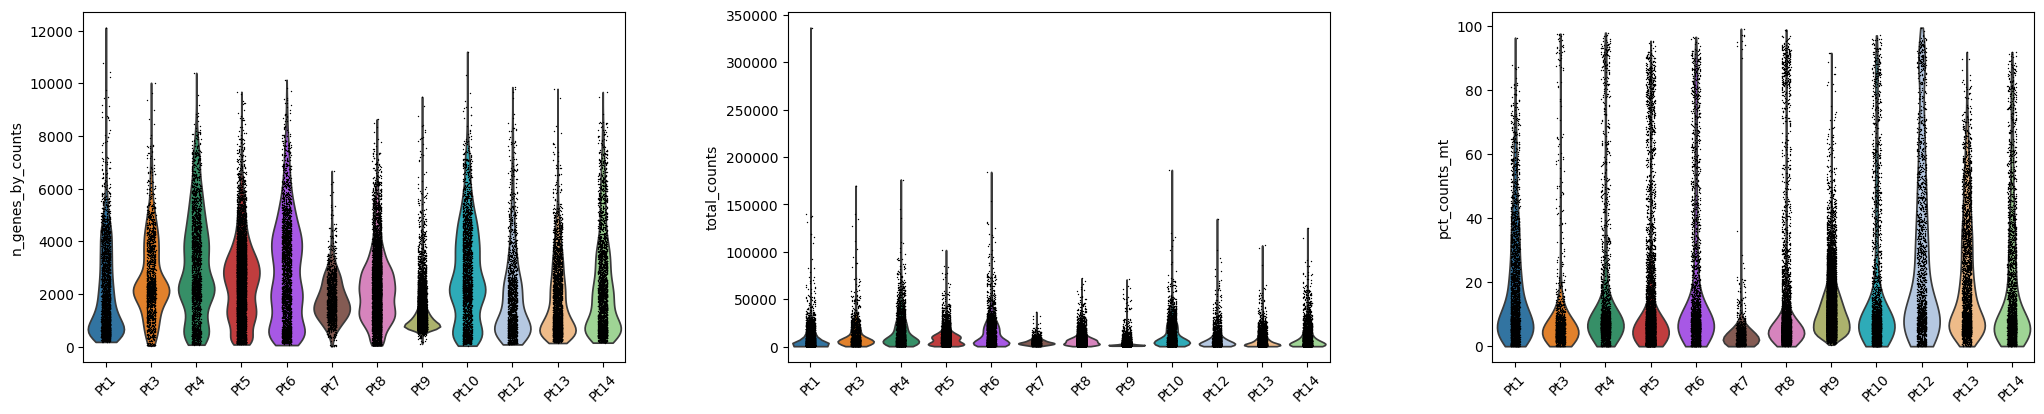

Before filtering: 49,360 cells


In [18]:
#Mitochondrial genes are often used as a quality control metric in single-cell RNA-seq data analysis because high mitochondrial gene expression can indicate stressed or dying cells.
# 'MT' for human data, 'Mt' for mouse data. Here we are using human data, so we look for 'MT'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, inplace=True, log1p=True)

# Always visualize BEFORE filtering
sc.pl.violin(adata, ['n_genes_by_counts','total_counts','pct_counts_mt'],
             groupby='patient_id', rotation=45, save='_QC_prefilter.pdf')

print(f"Before filtering: {adata.n_obs:,} cells")

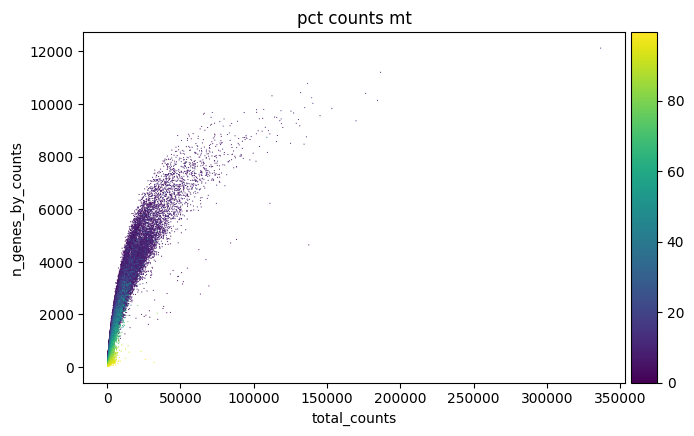

In [19]:
sc.pl.scatter(adata, 
              "total_counts", 
              "n_genes_by_counts", 
              color="pct_counts_mt", 
              groups="patient_id", 
              save='_QC_scatter.pdf')

<span style="font-size:12px">What can we see in the scatter plot? The rela

<span style="font-size:14px">Maybe we should create a **scatter plot for each patient**. This will help us set the thresholds for filtering out low-quality cells. We can look for cells with low total counts, low number of genes, and high percentage of mitochondrial gene expression, which are indicators of poor-quality cells.</span> 

<span style="font-size:14px">On the violin plots we can do the same, but the scatter plot will give us a more detailed and intuitive visualization to determine the appropriate thresholds for filtering.</span>

In [20]:
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf as pdf_backend

patients = adata.obs['patient_id'].cat.categories.tolist()

results_dir = Path(sc.settings.figdir)

# Create a multi-page PDF — one page per patient
with pdf_backend.PdfPages(results_dir / '_QC_scatter_by_patient.pdf') as pdf:
    for pid in tqdm(patients, desc='Plotting scatter per patient', unit='patient'):
        
        mask   = adata.obs['patient_id'] == pid
        subset = adata[mask]
        
        fig, ax = plt.subplots(figsize=(6, 5))
        
        scatter_plot = ax.scatter(
            subset.obs['total_counts'],
            subset.obs['n_genes_by_counts'],
            c=subset.obs['pct_counts_mt'],
            cmap='Reds',
            s=3,
            alpha=0.6
        )
        
        cbar = plt.colorbar(scatter_plot, ax=ax)
        cbar.set_label('% MT counts', fontsize=9)
        
        ax.set_xlabel('Total counts (UMIs)')
        ax.set_ylabel('N genes by counts')
        ax.set_title(f'{pid}  —  {subset.n_obs:,} cells  |  condition: {subset.obs["condition"][0]}')
        
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)          # ✅ free RAM after each plot

tqdm.write(f"✅ Saved: {results_dir / '_QC_scatter_by_patient.pdf'} ({len(patients)} pages)")

Plotting scatter per patient:   0%|          | 0/12 [00:00<?, ?patient/s]

C:\Users\dioul\AppData\Local\Temp\ipykernel_13268\2525280663.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_title(f'{pid}  —  {subset.n_obs:,} cells  |  condition: {subset.obs["condition"][0]}')
Plotting scatter per patient: 100%|██████████| 12/12 [00:09<00:00,  1.23patient/s]

✅ Saved: ..\results\_QC_scatter_by_patient.pdf (12 pages)


<span style="font-size:16px; color: yellow">**Filtering thresholds**</span>

<span style="font-size:14px">To identify poor-quality/ dead/stressed cells, we used the following thresholds: cells with few genes per cell **(<50)** or many molecules (unique molecular identifier counts) per cell **(>30,000)** and cells with **>20%** of the counts derived from mitochondrial genes. Such cells were removed before downstream analysis.

<span style="font-size:14px">**From Yan Mei et. al, 2023**

⚠️<span style="font-size:14px; color: orange">Even it's it not recommended to use the same thresholds for all patients because they are different batches, we will apply the same thresholds to all patients to maintain consistency across the dataset. This will allow us to compare the results across patients without introducing bias from different filtering criteria.👁️

In [ ]:
# ✅ UPDATED: chain filters with .copy() to avoid ImplicitModificationWarning
adata = adata[
    (adata.obs['n_genes_by_counts'] > 50) &               # Filter out cells with fewer than 50 genes detected (low complexity)
    (adata.obs['total_counts'] < 30000) &                  # Filter out cells with more than 30,000 total counts (potential doublets or multiplets)    
    (adata.obs['pct_counts_mt'] < 20)                      # Filter out cells with more than 20% mitochondrial counts (potentially stressed or dying cells)
].copy()  # ✅ UPDATED: .copy() prevents view-based modification warnings

print(f"After filtering:  {adata.n_obs:,} cells")

# ✅ UPDATED: save raw counts as a layer before any normalization
adata.layers['raw_counts'] = adata.X.copy()

adata.write_h5ad(ckpt_dir / 'adata_postQC.h5ad')
del adata; gc.collect()

After filtering:  37,887 cells


90750

<span style="font-size:16px; color: orange">**Note to consider**: Cells with a relatively high fraction of mitochondrial counts might for example be involved in respiratory processes and should not be filtered out. </span>

<span style="color: red; font-size:16px">**We filtered cells using <code>n_genes_by_counts > 50</code>. However, this is a very permissive threshold, as it allows many low-quality cells to pass quality control. Cells with such low gene counts are unlikely to provide meaningful biological information and often correspond to empty droplets, cellular debris, or ambient RNA contamination. This threshold should therefore be revised to ensure that downstream analyses are performed using high-quality data.**</span> 

<span style="font-size:14px">Literature suggests that a common threshold for filtering out low-quality cells is to require at least 200 genes per cell. This helps to ensure that we are retaining cells with sufficient gene expression information for meaningful analysis. By setting a threshold of >50 genes, we may be including many low-quality cells that could introduce noise and bias into our downstream analyses. Therefore, it would be advisable to increase the threshold to a more appropriate value, such as >350 genes per cell, to improve the quality of the dataset.</span>

In [22]:
adata = sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad')

print(f"Actual cells (>50 genes):   {adata.n_obs:,}")

# Apply the additional gene filter
adata = adata[adata.obs['n_genes_by_counts'] > 350].copy()

print(f"Cells after filtering (>350 genes):   {adata.n_obs:,}")

adata.write_h5ad(ckpt_dir / 'adata_postQC.h5ad')   # overwrite
del adata; gc.collect()

Actual cells (>50 genes):   37,887
Cells after filtering (>350 genes):   37,833


13

<span style="font-size:14px; color: green">**How about using MAD instead of fixed thresholds?**</span>

<span style="font-size:12px">***After clustering and seeing the distribution of QC metrics across clusters, we can adjust the thresholds for filtering out low-quality cells if needed.***</span>

<span style="font-size:16px; color: olive">**Flag ribosomal and hemoglobin genes to the filtered AnnData object**</span> 

In [25]:
adata=sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad')

adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
adata.var['hb']   = adata.var_names.str.contains(r'^HB[ABDEGMQZ]\d*(?!\w)')  #

# Recalculate to add ribo + hb columns to .obs
sc.pp.calculate_qc_metrics(                     #pp.calculate_qc_metrics() is a function in the Scanpy library that computes various quality control metrics for single-cell RNA-seq data.
    adata,
    qc_vars=['mt', 'ribo', 'hb'],
    percent_top=[20],                           #percent_top=[20] top 20% of counts for each cell will be calculated for the specified qc_vars (in this case, mitochondrial, ribosomal, and hemoglobin genes). 
    log1p=True,
    inplace=True
)

# Overwrite checkpoint with enriched metadata
adata.write_h5ad(ckpt_dir / 'adata_postQC.h5ad')

In [27]:
del adata; gc.collect() 

92302

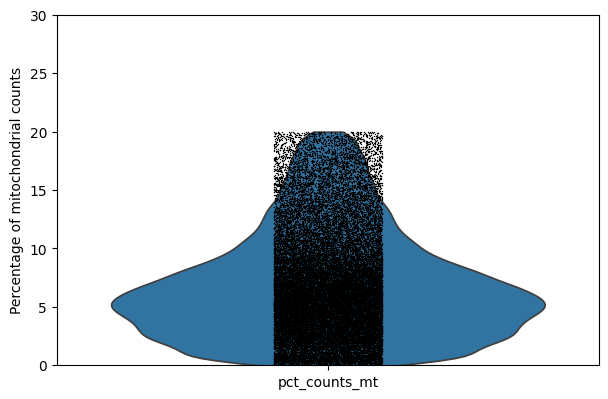

3343

In [33]:
adata=sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad')
ax=sc.pl.violin(adata, ['pct_counts_mt'],
             ylabel='Percentage of mitochondrial counts',
             show=False
             )
ax.set_ylim(0, 30) # Define the lower and upper limits of the Y-axis
plt.show()
del adata; gc.collect()


<span style="font-size:12px">**After violin plot, we can see that the percentage of mitochondrial counts is generally low across all patients, with most cells having less than 20% mitochondrial counts. Based on this observation, we can set a threshold of 20% for filtering out cells with high mitochondrial content. This means that any cell with more than 20% of its counts derived from mitochondrial genes will be flagged as an outlier and removed from downstream analysis. This threshold helps to ensure that we are retaining high-quality cells while filtering out potential low-quality or stressed cells.**</span>

<span style="font-size:16px; color:olive">**MAD-based outlier detection:**</span>

<span style="font-size:14px">To identify outliers in the QC metrics, we can use the Median Absolute Deviation (MAD) method. This involves calculating the median and MAD for each QC metric (e.g., number of genes, total counts, percentage of mitochondrial genes) and then identifying cells that fall outside a certain number of MADs from the median. This approach allows us to identify and filter out cells that are significantly different from the majority of cells in terms of their QC metrics, which may indicate low-quality or stressed cells.</span>

   - <span style="font-size:13px; color:olive">**Define a function to identify outliers based on MAD for a given QC metric.**</span>

In [34]:
# Define a function to identify outliers based on MAD for a given QC metric.
def is_outlier(adata, metric, n_mads=5):
    from scipy.stats import median_abs_deviation
    values = adata.obs[metric]
    median = np.median(values)
    mad = median_abs_deviation(values, scale='normal')
    lower_bound = median - n_mads * mad
    upper_bound = median + n_mads * mad
    return (values < lower_bound) | (values > upper_bound)

In [35]:
from scipy.stats import median_abs_deviation
adata=sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad')

adata.obs['outlier'] = (
    is_outlier(adata, 'log1p_total_counts', 5)
    | is_outlier(adata, 'log1p_n_genes_by_counts', 5)
    | is_outlier(adata, 'pct_counts_in_top_20_genes', 5)
)

MT_HARD_CAP = 20    # Cells with >20% mitochondrial counts are flagged as outliers regardless of MAD status
adata.obs['mt_outlier'] = (
    is_outlier(adata, 'pct_counts_mt', 3)
    | (adata.obs['pct_counts_mt'] > MT_HARD_CAP)
)

print(f"Before filtering:    {adata.n_obs:,} cells")
print(f"General outliers:    {adata.obs['outlier'].sum():,}")
print(f"MT outliers:         {adata.obs['mt_outlier'].sum():,}")

Before filtering:    37,833 cells
General outliers:    92
MT outliers:         380


   - <span style="font-size:13px; color:olive">**Filter cells based on MAD outliers:**</span>

In [36]:
adata = adata[
    (~adata.obs['outlier']) & (~adata.obs['mt_outlier'])
].copy()
print(f"After cell filter:   {adata.n_obs:,} cells")

After cell filter:   37,366 cells


<span style="font-size:16px; color: olive">**Filter lowly detected genes**</span>

In [37]:
print(f"Before gene filter:  {adata.n_vars:,} genes")
sc.pp.filter_genes(adata, min_cells=3)  # <-- Standard: is the baseline for removing background noise and uninformative genes
print(f"After gene filter:   {adata.n_vars:,} genes")

Before gene filter:  33,694 genes
filtered out 8339 genes that are detected in less than 3 cells
After gene filter:   25,355 genes


<span style="font-size:16px; color: olive">**Save raw counts layer + checkpoint**</span>

In [38]:
adata.layers['raw_counts'] = adata.X.copy()

adata.write_h5ad(ckpt_dir / 'adata_postQC.h5ad')
del adata; gc.collect()

1652

<span style="color:olive; font-size:22px">**DOUBLET DETECTION**</span>

<span style="font-size:14px">Doublets are <span style="color:yellow">artifacts that occur when **two cells are captured together**</span> during the single-cell RNA-seq process, leading to mixed gene expression profiles. Detecting and removing doublets is crucial for accurate downstream analysis. We will use the ***Scrublet library*** to identify potential doublets in our dataset. Scrublet simulates doublets by combining gene expression profiles of ***randomly selected pairs of cells*** and then uses a **machine learning approach** to classify real cells as singlets or doublets based on their similarity to the simulated doublets.</span>

<span style="font-size:14px">Identifying doublets is crucial as they can lead to misclassifications or distortions in downstream analysis steps.<br>
[**Scanpy tutorials**](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html)

<span style="color:slatergrey; font-size:14px">**Following best practices we will filter out doublets after clustering, as recommended by the Scrublet documentation and single-cell RNA-seq best practices.**</span>

<span style="font-size:14px">On this study we have 12 patients which a very heterogeneous number of cells per patient. To avoid biasing the doublet detection process, ***we will run Scrublet separately for each patient***. This approach allows us to account for differences in cell numbers and characteristics across patients, leading to more accurate identification of doublets within each individual dataset.</span>

In [ ]:
adata = sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad') 

adata.obs['doublet_score']     = np.nan
adata.obs['predicted_doublet'] = False

for pid in tqdm(adata.obs['patient_id'].unique(),
                desc='Scrublet per patient', unit='patient'):

    mask    = adata.obs['patient_id'] == pid
    n_cells = mask.sum()                    

    # Skip patients with too few cells
    if n_cells < 50:                # Patients with less than 50 cells may not provide enough data for reliable doublet detection. 
        tqdm.write(f"  {pid}: only {n_cells} cells — skipping Scrublet")
        continue

    # Adaptive doublet rate
    if n_cells < 2500:
        rate = 0.02
    elif n_cells < 5000:
        rate = 0.04
    elif n_cells < 8000:
        rate = 0.06
    else:
        rate = 0.08

    X     = adata[mask].X
    scrub = scr.Scrublet(X, expected_doublet_rate=rate)             #Scrublet is a Python library designed to identify and remove doublets from single-cell RNA-seq data. 

    scores, doublets = scrub.scrub_doublets(
        min_counts=2,               # Setting this to 2 allows Scrublet to consider genes that are detected in at least 2 cells, which can help improve the accuracy of doublet detection by focusing on more reliably detected genes.
        min_cells=3,
        n_prin_comps=min(30, max(10, n_cells // 100)),          # Use more PCs when sample size supports it, but keep the value in a safe range (10–30).
        verbose=False
    )

    adata.obs.loc[mask, 'doublet_score']     = scores
    adata.obs.loc[mask, 'predicted_doublet'] = doublets

    tqdm.write(f"  {pid}: {n_cells:,} cells | rate={rate} | "
               f"{doublets.sum()} doublets ({doublets.mean()*100:.1f}%)")

# pd.Categorical after loop
adata.obs['predicted_doublet'] = pd.Categorical(adata.obs['predicted_doublet'])

print(f"\n Doublets scored — not removed yet. Filtering after clustering.")

adata.obs['predicted_doublet'] = adata.obs['predicted_doublet'].astype(bool)
print(f"Total predicted doublets: {adata.obs['predicted_doublet'].sum():,}")

# Safety check for raw_counts layer
if 'raw_counts' not in adata.layers:
    adata.layers['raw_counts'] = adata.X.copy()

adata.write_h5ad(ckpt_dir / 'adata_postQC.h5ad')
del adata; gc.collect()

Scrublet per patient:   8%|▊         | 1/12 [00:04<00:54,  4.92s/patient]

  Pt1: 1,744 cells | rate=0.02 | 0 doublets (0.0%)


Scrublet per patient:  17%|█▋        | 2/12 [00:07<00:33,  3.33s/patient]

  Pt3: 1,339 cells | rate=0.02 | 5 doublets (0.4%)


Scrublet per patient:  25%|██▌       | 3/12 [00:10<00:29,  3.23s/patient]

...

Scrublet per patient:  92%|█████████▏| 11/12 [01:48<00:08,  8.48s/patient]

  Pt13: 1,677 cells | rate=0.02 | 7 doublets (0.4%)


Scrublet per patient: 100%|██████████| 12/12 [01:53<00:00,  9.44s/patient]


  Pt14: 1,701 cells | rate=0.02 | 3 doublets (0.2%)

 Doublets scored — not removed yet. Filtering after clustering.
Total predicted doublets: 361


456

<span style="font-size:16px; color: yellow">**After clustering consider these parameters for QC revision**</span>

   - <span style="font-size:14px">Ambient mRNA contamination.
   - <span style="font-size:14px">Cells involved in respiratory processes
   - <span style="font-size:14px">Large cells (high RNA content) or quiescent cells with low RNA content. 
   - <span style="font-size:14px">Ribosomal and hemoglobin genes, which can be highly expressed in certain cell types and may not necessarily indicate low-quality cells. (Already have the code) ✅